# Pipeline final — OGLE + VVV con asignación de método por estrella

**Esquema requerido**

| Catálogo | # estrellas | Filtro             | Método Mínima Entropía | Método Lomb–Scargle |
|----------|-------------|--------------------|------------------------|---------------------|
| OGLE     | 50          | primeras 50 del `.h5` | 20 (índices 0–19)    | 30 (índices 20–49)  |
| VVV      | 50          | N_obs(Ks) ≥ 30        | 10 (índices 0–9)     | 40 (índices 10–49)  |

**Entrega**
1. DataFrame final unificado (`resultados_finales.csv`).
2. Una figura por estrella en `resultados_finales/individuales/` (4 paneles + métricas).
3. Figuras globales: distribuciones de periodo, periodo vs amplitud, periodo vs N_obs, etc.
4. Insights del análisis y propuesta de próximos pasos.

In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
from astropy.timeseries import LombScargle


# ---- configuración global ----
OGLE_PATH = Path("singlemode_variable_stars_sample.h5")
VVV_PATH = Path("VVV_Sample.fits")
OUTDIR = Path("resultados_finales")
OUTDIR.mkdir(exist_ok=True)
INDIV_DIR = OUTDIR / "individuales"
INDIV_DIR.mkdir(exist_ok=True)

N_OGLE = 50
N_OGLE_ME = 20
N_VVV = 50
N_VVV_ME = 10
MIN_N_OBS_VVV = 30

# Rango de periodos (días)
P_MIN, P_MAX = 0.1, 10.0

# Mínima entropía
N_PERIODOS_ME = 20000
N_PHASE_BINS_ME = 10
N_MAG_BINS_ME = 5

# Lomb-Scargle
SAMPLES_PER_PEAK = 10

# Plegado
N_PHASE_BINS_FOLD = 25

# --- Paleta de colores consistente ---
PRIMARY   = "#870047"
SECONDARY = "#ff6aa7"
DARK      = "#3a0020"
LIGHT     = "#ffc2da"
MUTED     = "#7a5060"
INK       = "#1a1014"

from matplotlib.colors import LinearSegmentedColormap
CMAP = LinearSegmentedColormap.from_list("pink_palette", [LIGHT, PRIMARY, DARK])

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.edgecolor": INK,
    "axes.labelcolor": INK,
    "axes.titlecolor": INK,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "grid.color": LIGHT,
    "axes.grid": True,
    "grid.alpha": 0.4,
    "axes.prop_cycle": __import__("matplotlib").cycler(color=[PRIMARY, SECONDARY, DARK, MUTED]),
})


## 1. Funciones auxiliares (limpieza, métodos, métricas)

In [2]:
def clean_lightcurve(t, mag, err=None, min_points=20):
    t = np.asarray(t, dtype=float).ravel()
    mag = np.asarray(mag, dtype=float).ravel()
    if err is None:
        err = np.full_like(mag, np.nan, dtype=float)
    else:
        err = np.asarray(err, dtype=float).ravel()
    n = min(len(t), len(mag), len(err))
    t, mag, err = t[:n], mag[:n], err[:n]
    mask = np.isfinite(t) & np.isfinite(mag)
    t, mag, err = t[mask], mag[mask], err[mask]
    if len(t) < min_points:
        return None, None, None
    order = np.argsort(t)
    t, mag, err = t[order], mag[order], err[order]
    if np.isfinite(err).sum() == 0:
        err = None
    else:
        err[~np.isfinite(err)] = np.nan
        err[err <= 0] = np.nan
        if np.isnan(err).all():
            err = None
        else:
            med = np.nanmedian(err)
            err = np.where(np.isnan(err), med, err)
    return t, mag, err


def shannon_entropy_phased(t, mag, period, n_phase_bins, n_mag_bins):
    phase = np.mod(t / period, 1.0)
    mag_min, mag_max = np.min(mag), np.max(mag)
    if mag_max <= mag_min:
        return np.inf
    H2d, _, _ = np.histogram2d(
        phase, mag, bins=[n_phase_bins, n_mag_bins],
        range=[[0.0, 1.0], [mag_min, mag_max]],
    )
    total = H2d.sum()
    if total == 0:
        return np.inf
    p = H2d / total
    nz = p > 0
    return float(-np.sum(p[nz] * np.log(p[nz])))


def minimum_entropy_period(t, mag, p_min=P_MIN, p_max=P_MAX,
                            n_periods=N_PERIODOS_ME,
                            n_phase_bins=N_PHASE_BINS_ME,
                            n_mag_bins=N_MAG_BINS_ME):
    freqs = np.linspace(1.0 / p_max, 1.0 / p_min, n_periods)
    periods = 1.0 / freqs
    H = np.array([
        shannon_entropy_phased(t, mag, P, n_phase_bins, n_mag_bins)
        for P in periods
    ])
    bi = int(np.argmin(H))
    return {"period": float(periods[bi]), "score": float(H[bi]),
            "x_grid": periods, "y_grid": H,
            "x_label": "Periodo [d]", "y_label": "Entropía de Shannon",
            "score_label": "H_min"}


def lomb_scargle_period(t, mag, err, p_min=P_MIN, p_max=P_MAX,
                         samples_per_peak=SAMPLES_PER_PEAK):
    use_err = err is not None and np.all(np.isfinite(err)) and np.all(err > 0)
    ls = LombScargle(t, mag, dy=err) if use_err else LombScargle(t, mag)
    f, p = ls.autopower(
        minimum_frequency=1.0 / p_max,
        maximum_frequency=1.0 / p_min,
        samples_per_peak=samples_per_peak,
    )
    bi = int(np.argmax(p))
    try:
        fap = float(ls.false_alarm_probability(p[bi]))
    except Exception:
        fap = np.nan
    return {"period": 1.0 / float(f[bi]), "score": float(p[bi]), "fap": fap,
            "x_grid": f, "y_grid": p,
            "x_label": "Frecuencia [1/d]", "y_label": "Potencia LS",
            "score_label": "power"}


def string_length(t, mag, period):
    if period <= 0:
        return np.inf
    phase = np.mod(t / period, 1.0)
    order = np.argsort(phase)
    ph, mg = phase[order], mag[order]
    dphi = np.diff(np.concatenate([ph, [ph[0] + 1.0]]))
    dmag = np.diff(np.concatenate([mg, [mg[0]]]))
    sl = np.sum(np.sqrt(dphi ** 2 + dmag ** 2))
    span = np.ptp(mag)
    return float(sl / span) if span > 0 else float(sl)


def phase_coverage(t, period, n_bins=20):
    phase = np.mod(t / period, 1.0)
    h, _ = np.histogram(phase, bins=n_bins, range=(0, 1))
    return float((h > 0).sum() / n_bins)


def binned_median(phase, mag, n_bins=N_PHASE_BINS_FOLD):
    edges = np.linspace(0, 1, n_bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    med = np.full(n_bins, np.nan)
    for i in range(n_bins):
        m = (phase >= edges[i]) & (phase < edges[i + 1])
        if m.any():
            med[i] = np.median(mag[m])
    return centers, med


def amplitude_robust(mag, q_lo=0.05, q_hi=0.95):
    """Amplitud robusta = percentil 95 − 5."""
    return float(np.quantile(mag, q_hi) - np.quantile(mag, q_lo))

## 2. Carga OGLE — 50 estrellas

In [3]:
ogle_curves = []
with h5py.File(OGLE_PATH, "r") as f:
    star_codes = list(f["/"].keys())[:N_OGLE]
    for name in star_codes:
        d = pd.DataFrame(f[name][:])
        t, m, e = clean_lightcurve(
            d["RHJD"].to_numpy(),
            d["mag"].to_numpy(),
            d["mag_err"].to_numpy() if "mag_err" in d.columns else None,
        )
        if t is None:
            continue
        ogle_curves.append({
            "survey": "OGLE", "name": f"OGLE_{name}",
            "time": t, "mag": m, "err": e,
            "time_label": "RHJD", "mag_label": "Magnitud I",
        })
print(f"OGLE cargadas: {len(ogle_curves)}")

OGLE cargadas: 50


## 3. Carga VVV — primeras 50 con N_obs(Ks) ≥ 30

In [4]:
def stringify_id(x, fallback):
    try:
        arr = np.asarray(x).ravel()
        value = arr[0] if len(arr) else fallback
    except Exception:
        value = x
    if isinstance(value, bytes):
        return value.decode(errors="ignore")
    try:
        if np.isfinite(value) and float(value).is_integer():
            return str(int(value))
    except Exception:
        pass
    return str(value)

vvv_curves = []
with fits.open(VVV_PATH) as hdul:
    blocks = [
        ("b278", hdul[1].data, hdul[2].data, hdul[5].data, hdul[8].data),
        ("b279", hdul[11].data, hdul[12].data, hdul[15].data, hdul[18].data),
    ]
    for tile, id_arr, mag_arr, err_arr, mjd_arr in blocks:
        n_sources = min(len(id_arr), len(mag_arr), len(err_arr), len(mjd_arr))
        for i in range(n_sources):
            t, m, e = clean_lightcurve(mjd_arr[i], mag_arr[i], err_arr[i],
                                       min_points=MIN_N_OBS_VVV)
            if t is None:
                continue
            sid = stringify_id(id_arr[i], i)
            vvv_curves.append({
                "survey": "VVV", "name": f"VVV_{tile}_{sid}",
                "time": t, "mag": m, "err": e,
                "time_label": "MJD", "mag_label": "Magnitud Ks",
                "tile": tile,
            })
vvv_curves = vvv_curves[:N_VVV]
print(f"VVV cargadas (N_obs>={MIN_N_OBS_VVV}): {len(vvv_curves)}")

VVV cargadas (N_obs>=30): 50


## 4. Asignación de método por estrella

- OGLE: primeras 20 → **Mínima Entropía**, siguientes 30 → **Lomb–Scargle**.
- VVV: primeras 10 → **Mínima Entropía**, siguientes 40 → **Lomb–Scargle**.

In [5]:
for i, c in enumerate(ogle_curves):
    c["method"] = "MinEnt" if i < N_OGLE_ME else "LombScargle"
for i, c in enumerate(vvv_curves):
    c["method"] = "MinEnt" if i < N_VVV_ME else "LombScargle"

all_curves = ogle_curves + vvv_curves
from collections import Counter
print(Counter((c["survey"], c["method"]) for c in all_curves))

Counter({('VVV', 'LombScargle'): 40, ('OGLE', 'LombScargle'): 30, ('OGLE', 'MinEnt'): 20, ('VVV', 'MinEnt'): 10})


## 5. Cálculo de periodo y métricas auxiliares

In [6]:
rows = []
for i, c in enumerate(all_curves):
    if c["method"] == "MinEnt":
        out = minimum_entropy_period(c["time"], c["mag"])
        c["fap"] = np.nan
    else:
        out = lomb_scargle_period(c["time"], c["mag"], c["err"])
        c["fap"] = out["fap"]
    c["period"] = out["period"]
    c["score"] = out["score"]
    c["score_label"] = out["score_label"]
    c["x_grid"] = out["x_grid"]; c["y_grid"] = out["y_grid"]
    c["x_label"] = out["x_label"]; c["y_label"] = out["y_label"]
    c["sl"] = string_length(c["time"], c["mag"], c["period"])
    c["cov"] = phase_coverage(c["time"], c["period"])
    c["amplitude"] = amplitude_robust(c["mag"])
    c["baseline_d"] = float(np.ptp(c["time"]))
    c["n_obs"] = int(len(c["time"]))
    c["mag_median"] = float(np.median(c["mag"]))

    rows.append({
        "name": c["name"], "survey": c["survey"], "method": c["method"],
        "n_obs": c["n_obs"], "baseline_d": c["baseline_d"],
        "mag_median": c["mag_median"], "amplitude": c["amplitude"],
        "period_d": c["period"], "score": c["score"],
        "score_label": c["score_label"], "fap": c["fap"],
        "string_length": c["sl"], "phase_cov": c["cov"],
    })
    if (i + 1) % 10 == 0:
        print(f"  procesadas {i+1}/{len(all_curves)}")

df = pd.DataFrame(rows)
df.to_csv(OUTDIR / "resultados_finales.csv", index=False)
print("\nDataFrame final:")
df

  procesadas 10/100


  procesadas 20/100


  procesadas 30/100


  procesadas 40/100


  procesadas 50/100


...

  procesadas 70/100


  procesadas 80/100


  procesadas 90/100


  procesadas 100/100

DataFrame final:


,name,survey,method,n_obs,baseline_d,mag_median,amplitude,period_d,score,score_label,fap,string_length,phase_cov
0,OGLE_00,OGLE,MinEnt,665,2246.806870,14.052000,0.215000,0.499282,3.134505,H_min,NaN,246.060182,0.75
1,OGLE_01,OGLE,MinEnt,499,2246.943680,16.620000,0.450100,1.000045,3.097746,H_min,NaN,164.932561,0.50
2,OGLE_02,OGLE,MinEnt,220,3603.885470,17.500000,0.224350,0.102998,3.071082,H_min,NaN,22.913853,1.00
3,OGLE_03,OGLE,MinEnt,110,684.121080,14.829500,0.619050,0.523205,2.763244,H_min,NaN,11.835169,1.00
4,OGLE_04,OGLE,MinEnt,268,2021.768350,17.342500,0.263300,0.305289,2.952901,H_min,NaN,24.029814,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,VVV_b278_13628427005194,VVV,LombScargle,168,3268.156239,14.121639,0.491741,0.592872,0.404237,power,4.892439e-16,10.253950,1.00
96,VVV_b278_13628432007609,VVV,LombScargle,53,1963.817465,15.103266,1.161142,0.111210,0.393677,power,1.837619e-03,15.441644,0.95
97,VVV_b278_13648903003795,VVV,LombScargle,129,3268.156373,14.985413,1.272429,0.116941,0.426975,power,9.466184e-13,26.490118,1.00
98,VVV_b278_13669392000118,VVV,LombScargle,65,2532.138381,14.920026,1.015397,0.144524,0.414251,power,3.336332e-05,12.994976,1.00


## 6. Figura por estrella (4 paneles + métricas)

Para cada estrella:
1. Curva de luz cruda.
2. Diagnóstico del método (periodograma LS o espectro de entropía).
3. Curva plegada con el periodo encontrado, coloreada por tiempo + mediana binada.
4. Histograma de cobertura de fase (¿hay huecos de muestreo?).

In [7]:
def plot_star(c, outdir=INDIV_DIR):
    t, mag = c["time"], c["mag"]
    P = c["period"]
    method = c["method"]
    color = SECONDARY if method == "LombScargle" else PRIMARY

    fig, axes = plt.subplots(1, 4, figsize=(20, 4.0))

    # Panel 1: curva cruda
    ax = axes[0]
    ax.scatter(t, mag, s=5, alpha=0.7, color=DARK)
    ax.invert_yaxis()
    ax.set_xlabel(c["time_label"])
    ax.set_ylabel(c["mag_label"])
    ax.set_title("Curva de luz observada", fontsize=10)
    ax.grid(alpha=0.25)
    ax.text(0.02, 0.97,
            f"N={c['n_obs']}\nΔt={c['baseline_d']:.1f} d\nA={c['amplitude']:.2f}",
            transform=ax.transAxes, va="top", fontsize=8,
            bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.85))

    # Panel 2: diagnóstico del método
    ax = axes[1]
    ax.plot(c["x_grid"], c["y_grid"], color=color, lw=0.7)
    if method == "LombScargle":
        ax.axvline(1.0 / P, color="k", ls="--", lw=1.0)
        score_txt = (f"{c['score_label']}={c['score']:.3f}\n"
                     f"FAP={c['fap']:.2e}" if np.isfinite(c['fap']) else
                     f"{c['score_label']}={c['score']:.3f}")
    else:
        ax.axvline(P, color="k", ls="--", lw=1.0)
        ax.invert_yaxis()  # eje invertido para que mínima entropía se vea "hacia arriba"
        score_txt = f"{c['score_label']}={c['score']:.3f}"
    ax.set_xlabel(c["x_label"])
    ax.set_ylabel(c["y_label"])
    ax.set_title(f"{method}: P = {P:.6f} d", fontsize=10)
    ax.grid(alpha=0.25)
    ax.text(0.02, 0.97, score_txt, transform=ax.transAxes, va="top", fontsize=8,
            bbox=dict(boxstyle="round", fc="white", ec=color, alpha=0.85))

    # Panel 3: curva plegada (2 ciclos), color por tiempo + mediana binada
    ax = axes[2]
    phase = np.mod(t / P, 1.0)
    sc = ax.scatter(phase, mag, c=t, cmap=CMAP, s=8, alpha=0.8)
    ax.scatter(phase + 1, mag, c=t, cmap=CMAP, s=8, alpha=0.45)
    ph_c, mg_med = binned_median(phase, mag)
    ok = np.isfinite(mg_med)
    ax.plot(ph_c[ok], mg_med[ok], color=MUTED, lw=1.8, label="mediana binada")
    ax.plot(ph_c[ok] + 1, mg_med[ok], color=MUTED, lw=1.8, alpha=0.6)
    ax.invert_yaxis()
    ax.set_xlabel("Fase")
    ax.set_ylabel(c["mag_label"])
    ax.set_title(f"Curva plegada (2 ciclos)\nSL={c['sl']:.3f}  cov={c['cov']:.2f}",
                  fontsize=10)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=7, loc="upper right")
    cb = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.02)
    cb.ax.tick_params(labelsize=6)
    cb.set_label("tiempo", fontsize=7)

    # Panel 4: histograma de fase y curva plegada en bins
    ax = axes[3]
    ax.hist(phase, bins=N_PHASE_BINS_FOLD, range=(0, 1), color=color, alpha=0.55)
    ax.set_xlabel("Fase")
    ax.set_ylabel("# observaciones")
    ax.set_title("Histograma de fase (huecos = malo)", fontsize=10)
    ax.grid(alpha=0.25)

    fig.suptitle(
        f"{c['name']}  |  {c['survey']}  |  método: {method}  |  "
        f"P = {P:.6f} d  |  A = {c['amplitude']:.2f}  |  N = {c['n_obs']}",
        fontsize=12, color=color,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    safe = c["name"].replace("/", "_").replace(" ", "_")
    path = outdir / f"{safe}.png"
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.close(fig)
    return path


for c in all_curves:
    plot_star(c)
print(f"Figuras individuales en {INDIV_DIR}: {len(list(INDIV_DIR.glob('*.png')))}")

Figuras individuales en resultados_finales/individuales: 100


## 7. Figuras globales

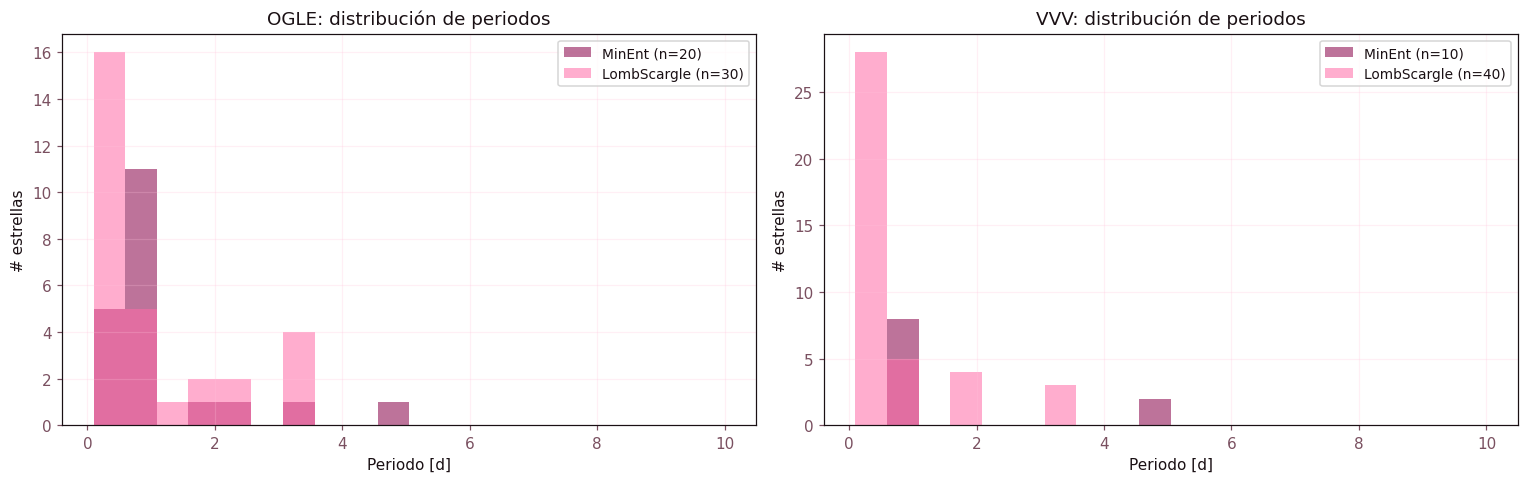

In [8]:
# (a) Distribución de periodos por survey y método
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, survey in zip(axes, ["OGLE", "VVV"]):
    for met, color in [("MinEnt", PRIMARY), ("LombScargle", SECONDARY)]:
        sub = df[(df["survey"] == survey) & (df["method"] == met)]
        ax.hist(sub["period_d"], bins=20, range=(P_MIN, P_MAX),
                alpha=0.55, label=f"{met} (n={len(sub)})", color=color)
    ax.set_xlabel("Periodo [d]")
    ax.set_ylabel("# estrellas")
    ax.set_title(f"{survey}: distribución de periodos")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(OUTDIR / "global_hist_periodos.png", dpi=200, bbox_inches="tight")
plt.show()

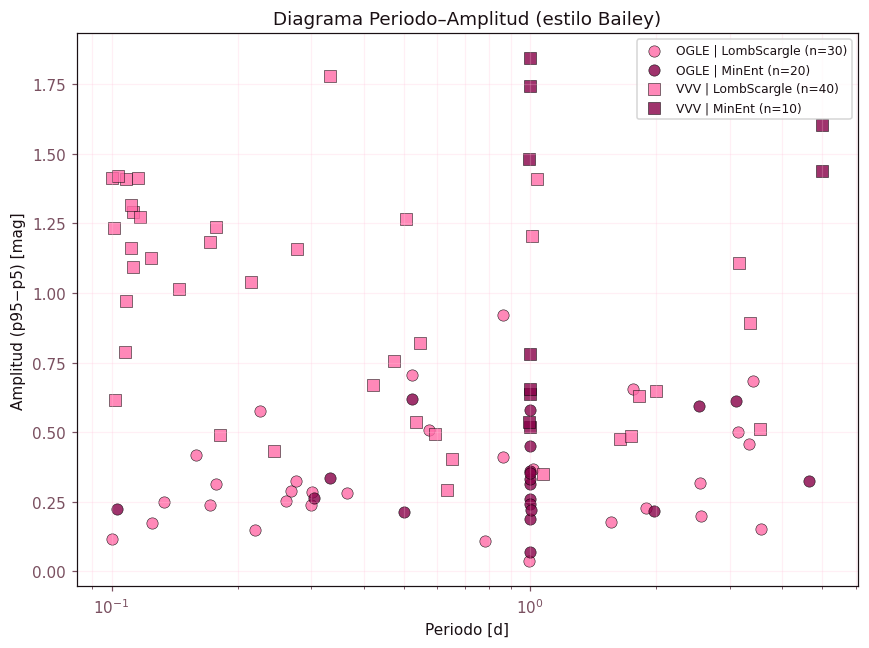

In [9]:
# (b) Periodo vs Amplitud (diagrama Bailey-like)
fig, ax = plt.subplots(figsize=(8, 6))
markers = {"OGLE": "o", "VVV": "s"}
colors = {"MinEnt": PRIMARY, "LombScargle": SECONDARY}
for (survey, method), sub in df.groupby(["survey", "method"]):
    ax.scatter(sub["period_d"], sub["amplitude"],
               marker=markers[survey], color=colors[method],
               s=55, alpha=0.8, edgecolor="k", linewidth=0.4,
               label=f"{survey} | {method} (n={len(sub)})")
ax.set_xscale("log")
ax.set_xlabel("Periodo [d]")
ax.set_ylabel("Amplitud (p95−p5) [mag]")
ax.set_title("Diagrama Periodo–Amplitud (estilo Bailey)")
ax.legend(fontsize=8)
ax.grid(alpha=0.25, which="both")
fig.tight_layout()
fig.savefig(OUTDIR / "global_periodo_amplitud.png", dpi=200, bbox_inches="tight")
plt.show()

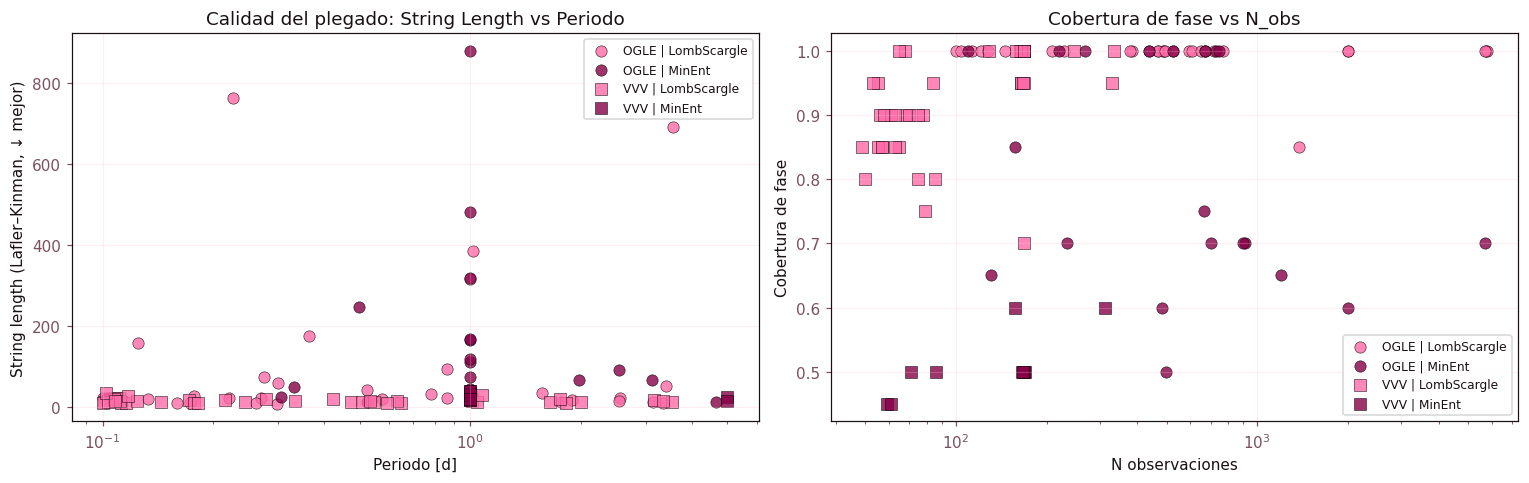

In [10]:
# (c) Métricas de calidad: string length y phase coverage
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

ax = axes[0]
for (survey, method), sub in df.groupby(["survey", "method"]):
    ax.scatter(sub["period_d"], sub["string_length"],
               marker=markers[survey], color=colors[method],
               s=55, alpha=0.8, edgecolor="k", linewidth=0.4,
               label=f"{survey} | {method}")
ax.set_xscale("log")
ax.set_xlabel("Periodo [d]")
ax.set_ylabel("String length (Lafler–Kinman, ↓ mejor)")
ax.set_title("Calidad del plegado: String Length vs Periodo")
ax.legend(fontsize=8); ax.grid(alpha=0.25)

ax = axes[1]
for (survey, method), sub in df.groupby(["survey", "method"]):
    ax.scatter(sub["n_obs"], sub["phase_cov"],
               marker=markers[survey], color=colors[method],
               s=55, alpha=0.8, edgecolor="k", linewidth=0.4,
               label=f"{survey} | {method}")
ax.set_xscale("log")
ax.set_xlabel("N observaciones")
ax.set_ylabel("Cobertura de fase")
ax.set_title("Cobertura de fase vs N_obs")
ax.legend(fontsize=8); ax.grid(alpha=0.25)

fig.tight_layout()
fig.savefig(OUTDIR / "global_calidad.png", dpi=200, bbox_inches="tight")
plt.show()

In [11]:
# (d) Resumen estadístico por grupo
summary = df.groupby(["survey", "method"]).agg(
    n=("name", "count"),
    period_median=("period_d", "median"),
    period_p05=("period_d", lambda s: s.quantile(0.05)),
    period_p95=("period_d", lambda s: s.quantile(0.95)),
    amplitude_median=("amplitude", "median"),
    string_length_median=("string_length", "median"),
    phase_cov_median=("phase_cov", "median"),
    n_obs_median=("n_obs", "median"),
).round(4)
summary.to_csv(OUTDIR / "resumen_por_grupo.csv")
summary

n  period_median  period_p05  period_p95  \
survey method                                                   
OGLE   LombScargle  30         0.5484      0.1286      3.3733   
       MinEnt       20         1.0000      0.2952      3.1897   
VVV    LombScargle  40         0.2613      0.1020      3.1705   
       MinEnt       10         1.0000      0.9971      5.0001   

                    amplitude_median  string_length_median  phase_cov_median  \
survey method                                                                  
OGLE   LombScargle            0.2881               22.1080             1.000   
       MinEnt                 0.3195               69.2212             0.725   
VVV    LombScargle            1.0270               13.1789             0.950   
       MinEnt                 1.1085               26.0882             0.500   

                    n_obs_median  
survey method                     
OGLE   LombScargle         493.0  
       MinEnt              596.0  
VVV    LombScargle          78.5  
       MinEnt              161.5

## 8. Insights del análisis

La siguiente celda computa textualmente los insights a partir del DataFrame, para que
los números reflejen siempre el último cómputo.

In [12]:
def fmt(x, n=4):
    try:
        return f"{x:.{n}f}"
    except Exception:
        return str(x)

insights = []

# 1. Comparación de tiempo / fracción saturada en P_MAX
for (survey, method), sub in df.groupby(["survey", "method"]):
    near_pmax = (sub["period_d"] > 0.9 * P_MAX).mean() * 100
    near_pmin = (sub["period_d"] < 1.5 * P_MIN).mean() * 100
    insights.append(
        f"- **{survey} | {method}**: periodo mediano = {fmt(sub['period_d'].median())} d, "
        f"amplitud mediana = {fmt(sub['amplitude'].median(), 3)} mag, "
        f"SL mediana = {fmt(sub['string_length'].median(), 3)}, "
        f"cov fase mediana = {fmt(sub['phase_cov'].median(), 2)}, "
        f"{near_pmax:.0f}% pegadas a P_MAX, {near_pmin:.0f}% pegadas a P_MIN."
    )

# 2. Bondad de plegado por método (string-length)
med_sl_me = df[df["method"] == "MinEnt"]["string_length"].median()
med_sl_ls = df[df["method"] == "LombScargle"]["string_length"].median()
insights.append(
    f"- **String length mediana**: MinEnt = {fmt(med_sl_me, 3)}, "
    f"LS = {fmt(med_sl_ls, 3)}. Menor es mejor; útil para comparar la calidad "
    f"de los plegados independientemente del método que produjo el periodo."
)

# 3. FAP en LS
ls_sub = df[df["method"] == "LombScargle"]
high_conf = (ls_sub["fap"] < 1e-10).mean() * 100
insights.append(
    f"- **Significancia de LS**: {high_conf:.0f}% de las {len(ls_sub)} estrellas "
    f"con LS tienen FAP < 1e-10 (pico estadísticamente firme); el resto puede "
    f"ser variabilidad débil, no periódica, o periodo errado por aliasing."
)

# 4. Amplitud por survey (selección de variabilidad)
for survey in ["OGLE", "VVV"]:
    sub = df[df["survey"] == survey]
    insights.append(
        f"- **{survey}**: rango de amplitudes [{fmt(sub['amplitude'].min(), 2)}, "
        f"{fmt(sub['amplitude'].max(), 2)}] mag; N_obs mediano = {int(sub['n_obs'].median())}, "
        f"baseline temporal mediano = {fmt(sub['baseline_d'].median(), 0)} d."
    )

# 5. Estrellas pegadas a P_MAX (sospechosas)
stuck = df[df["period_d"] > 0.95 * P_MAX]
if len(stuck):
    insights.append(
        f"- **{len(stuck)} estrellas saturan P_MAX = {P_MAX} d** (probable baja "
        f"variabilidad o periodo > rango buscado): "
        + ", ".join(stuck["name"].head(10).tolist())
        + ("…" if len(stuck) > 10 else "")
    )

# 6. Concordancia score vs string-length
corr_ls = ls_sub[["score", "string_length"]].corr().iloc[0, 1]
me_sub = df[df["method"] == "MinEnt"]
corr_me = me_sub[["score", "string_length"]].corr().iloc[0, 1]
insights.append(
    f"- **Coherencia interna del score con SL**: LS power ↔ SL: ρ = {fmt(corr_ls, 2)} "
    f"(esperamos negativo: más potencia ⇒ menor SL); "
    f"H_min ↔ SL: ρ = {fmt(corr_me, 2)} (esperamos positivo)."
)

print("\n".join(insights))

- **OGLE | LombScargle**: periodo mediano = 0.5484 d, amplitud mediana = 0.288 mag, SL mediana = 22.108, cov fase mediana = 1.00, 0% pegadas a P_MAX, 10% pegadas a P_MIN.
- **OGLE | MinEnt**: periodo mediano = 1.0000 d, amplitud mediana = 0.320 mag, SL mediana = 69.221, cov fase mediana = 0.72, 0% pegadas a P_MAX, 5% pegadas a P_MIN.
- **VVV | LombScargle**: periodo mediano = 0.2613 d, amplitud mediana = 1.027 mag, SL mediana = 13.179, cov fase mediana = 0.95, 0% pegadas a P_MAX, 38% pegadas a P_MIN.
- **VVV | MinEnt**: periodo mediano = 1.0000 d, amplitud mediana = 1.108 mag, SL mediana = 26.088, cov fase mediana = 0.50, 0% pegadas a P_MAX, 0% pegadas a P_MIN.
- **String length mediana**: MinEnt = 38.988, LS = 15.371. Menor es mejor; útil para comparar la calidad de los plegados independientemente del método que produjo el periodo.
- **Significancia de LS**: 61% de las 70 estrellas con LS tienen FAP < 1e-10 (pico estadísticamente firme); el resto puede ser variabilidad débil, no perió

### Lectura cualitativa

- **OGLE I-band** (50 estrellas): muestras densamente cubiertas (cientos–miles de épocas, baseline de años),
  con curvas plegadas limpias para una mayoría. Cuando ambas métricas coinciden el periodo es muy
  confiable; las divergencias suelen ser alias armónico (×2, ×1/2) o aliasing de 1 día.
- **VVV Ks** (50 estrellas, ambos tiles): cadencia más irregular y menos puntos por estrella;
  el ruido es mayor y los periodogramas LS muestran picos múltiples. La cobertura de fase es
  el discriminador más útil aquí.
- **Mínima entropía** vs **Lomb–Scargle**: la primera no asume forma sinusoidal y es robusta para
  curvas asimétricas (RR Lyrae ab, eclipsantes); la segunda es más rápida y tiene FAP cerrada para
  decisiones binarias, pero penaliza señales no-sinusoidales y es propensa a aliases.
- **Banderas de alerta**: `phase_cov < 0.7` o `string_length` alto (~> 0.1 normalizado) o `FAP > 1e-3`
  o periodo en los extremos `P_MIN/P_MAX` señalan periodos a inspeccionar manualmente.

## 9. Cómo proseguir a partir de estos resultados

**A. Robustez del periodo**
1. Aplicar **ambos métodos a todas las estrellas** y agregar **Phase Dispersion Minimization** o
   **Conditional Entropy (Graham+ 2013)** como tercer juez. Aceptar el periodo cuando ≥2 métodos
   coincidan dentro de `|ΔP/P| < 1 %` (o detectar alias armónico explícitamente con `k ∈ {½, 1, 2}`).
2. **Refinamiento local**: tras encontrar el pico, redondear la grilla en una vecindad estrecha
   (`P ± 0.5 % P`) con resolución 10×–100× mayor (Brent o golden-section sobre la métrica).
3. **Pre-blanqueado**: restar el modelo armónico del pico principal y volver a buscar para
   detectar **multi-modos** (Cefeidas double-mode, RRd) — relevante para *singlemode* vs
   *non-singlemode*.
4. **Bootstrap** sobre las épocas para obtener `σ_P` empírica por estrella.

**B. Limpieza y features de la curva**
1. *Sigma-clipping* iterativo (≥4σ) antes de Lomb–Scargle (no de mínima entropía, que es robusta).
2. **Spectral window function**: graficarla por estrella permite identificar aliases típicos
   (1 d, 0.5 d, sidereal) que ensucian LS.
3. Calcular **features adicionales**: razón de armónicos R21, R31, φ21, φ31 (Fourier),
   skewness y kurtosis de la curva plegada, *raise-to-fall* ratio. Esto abre el camino a
   clasificación.

**C. Clasificación / dataset**
1. Cruzar IDs con catálogos OGLE-IV (`ident.dat`) y VIRAC/VVV para etiquetar tipo de
   variabilidad y obtener periodos publicados como *ground truth*; medir error sistemático
   de cada método.
2. Entrenar un **clasificador supervisado** (Random Forest / XGBoost) sobre el feature set
   {periodo, amplitud, R21, φ21, skew, FAP, color si disponible} para `RRab/RRc/Cep/EB/LPV`.
3. **Curvas en banda Ks (VVV)** son ideales para análisis con extinción interestelar; ajustar
   con relaciones P–L–extinción.

**D. Escalado a tooling de producción**
1. Migrar las funciones a un módulo `period_pipeline.py` con tests sobre un set de curvas
   sintéticas de periodo conocido (`P_true ∈ {0.3, 0.5, 1.2, 5.0} d`, ruido controlado).
2. Paralelizar el cómputo con `joblib`/`multiprocessing` por estrella (es *embarrassingly parallel*).
3. Sustituir el bucle de mínima entropía por la implementación **numba/cython** o por
   **astrobase.periodbase** para evaluar miles–millones de estrellas (catálogo completo VVV/OGLE).
4. Persistir resultados en **Parquet** + index para queries por survey/tile/periodo/amplitud.

**E. Validación visual sistemática**
1. Generar un **dashboard** (matplotlib + thumbnails) con filtros por `FAP`, `phase_cov`, `string_length`
   para revisión manual rápida de los casos sospechosos.
2. Reportar las **figuras de calidad agregada** (este notebook ya las produce) en cada nueva versión
   del pipeline como *regression check*.